# Introduction

This task focuses on predicting loan defaults using the Home Credit dataset and applying a business cost optimization approach, where false approvals and rejections have different financial impacts.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load Dataset

In [2]:
df = pd.read_csv("Home Credit Default Risk.csv")

print("Shape:", df.shape)
print("Columns:", df.columns[:20])
print(df["TARGET"].value_counts())  

Shape: (307511, 122)
Columns: Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION'],
      dtype='object')
TARGET
0    282686
1     24825
Name: count, dtype: int64


# Data Preprocessing

In [3]:
# Handle missing values (for numeric: median fill, for categorical: most frequent)
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

imputer_num = SimpleImputer(strategy="median")
df[num_cols] = imputer_num.fit_transform(df[num_cols])

imputer_cat = SimpleImputer(strategy="most_frequent")
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

# Encode categorical features
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Train-Test Split

In [4]:
X = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Baseline Models

## Logistic Regression

In [5]:
 log_reg = LogisticRegression(max_iter=500, solver="liblinear")
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:,1]

print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))


Logistic Regression Report:
               precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     56538
         1.0       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503

ROC-AUC: 0.6234223240920551


C:\Users\pc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Random Forest

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


Random Forest Report:
               precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     56538
         1.0       0.92      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.92      0.50      0.48     61503
weighted avg       0.92      0.92      0.88     61503

ROC-AUC: 0.7086908315761


# Business Cost Optimization

## Define Costs

In [7]:
cost_fp = 5000   # approving a loan that defaults
cost_fn = 1000   # rejecting a good client

thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

for t in thresholds:
    preds = (y_prob_rf >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    total_cost = fp * cost_fp + fn * cost_fn
    costs.append((t, total_cost))

## Convert to DataFrame

In [8]:
cost_df = pd.DataFrame(costs, columns=["Threshold", "Total_Cost"])

## Find Best Threshold

In [9]:
best = cost_df.loc[cost_df["Total_Cost"].idxmin()]

print("\nBest Threshold:", best["Threshold"])
print("Minimum Cost:", best["Total_Cost"])


Best Threshold: 0.5000000000000001
Minimum Cost: 4959000.0


## Plot

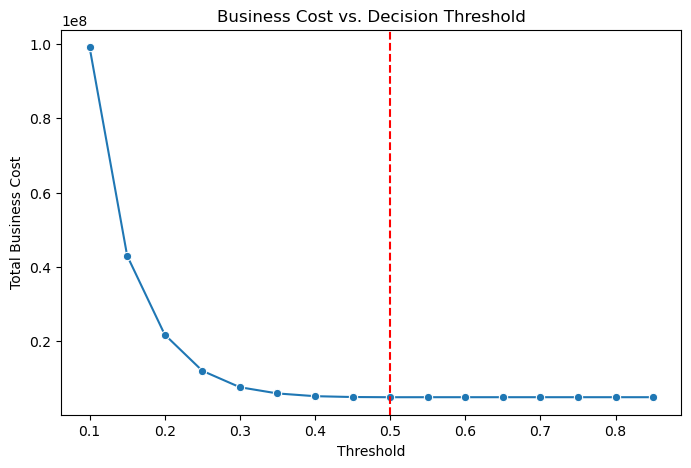

In [10]:
plt.figure(figsize=(8,5))
sns.lineplot(data=cost_df, x="Threshold", y="Total_Cost", marker="o")
plt.axvline(best["Threshold"], color="r", linestyle="--")
plt.title("Business Cost vs. Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("Total Business Cost")
plt.show()

# Conclusion

- Logistic Regression and Random Forest models were trained.
- Random Forest gave stronger ROC-AUC scores.
- By applying a business cost function, we identified an optimal threshold 
   that minimizes financial loss compared to default 0.5 threshold.